In [1]:
# Cell 1: Cấu hình mô phỏng ⚙️
import torch
torch.cuda.empty_cache()
class SimulationConfig:
    # === 1. Cấu hình thuật toán và mô phỏng ===
    ALGORITHM = 'fedavg' # 'fedavg', 'fedprox'
    NUM_ROUNDS = 200
    
    # === 2. Cấu hình huấn luyện tại Client ===
    LOCAL_EPOCHS = 5
    BATCH_SIZE = 16
    LEARNING_RATE = 0.01

    # === 3. Tham số riêng cho thuật toán ===
    FEDPROX_MU = 0.01

    # === 4. Cấu hình hệ thống và đường dẫn ===
    CONFIG_PATH = '../configs/config.yaml'
    DATA_PATH = '../data'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

config = SimulationConfig()

In [2]:
# Cell 2: Tải cấu hình và chuẩn bị dữ liệu 📦
import yaml, torch, numpy as np, time, copy, os
import matplotlib.pyplot as plt
from torch import nn
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from src.dataset_preparation import prepare_data
from src.monitoring_utils import ResourceMonitor, shutdown_pynvml
# Thiết lập seed
torch.manual_seed(config.SEED); np.random.seed(config.SEED)

# Đọc file config
print(f"Đang đọc file cấu hình từ: {config.CONFIG_PATH}")
with open(config.CONFIG_PATH, 'r') as f:
    loaded_config = yaml.safe_load(f)
data_params = loaded_config['data_config']
print(f"Đã tải cấu hình dữ liệu: {data_params}")

# Chuẩn bị dữ liệu dựa trên config đã đọc
client_loaders, test_loader, class_names = prepare_data(
    data_path=config.DATA_PATH,
    batch_size=config.BATCH_SIZE,
    seed=config.SEED,
    **data_params  # Sử dụng các tham số từ file yaml, bao gồm cả 'num_clients'
)

# SUY RA SỐ CLIENT TỪ DỮ LIỆU
num_clients = len(client_loaders)
print(f"\nĐã khởi tạo dữ liệu cho {num_clients} client.")
print(f"Sử dụng thiết bị: {config.DEVICE}")

Đang đọc file cấu hình từ: ../configs/config.yaml
Đã tải cấu hình dữ liệu: {'dataset_name': 'cifar10', 'distribution_mode': 'iid', 'num_clients': 50, 'shards_per_client': 2, 'dirichlet_alpha': 0.5}

Đã khởi tạo dữ liệu cho 50 client.
Sử dụng thiết bị: cuda


In [3]:
# Cell 3: Định nghĩa mô hình Neural Network 🧠
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, input_size=32):
        super(SimpleCNN, self).__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16 -> 8
        )
        # Kích thước sau lớp conv cuối cùng: 64 channels * (input_size/4) * (input_size/4)
        feature_size = (input_size // 4) ** 2 * 64
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feature_size, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.fc_stack(self.conv_stack(x))

In [4]:
# Cell 4: Logic cốt lõi của Federated Learning 🤖
def client_update(client_loader, model):
    # Khởi tạo trình theo dõi
    monitor = ResourceMonitor()
    monitor.start()
    
    start_time = time.time()
    local_model = copy.deepcopy(model).to(config.DEVICE)
    local_model.train()
    optimizer = torch.optim.SGD(local_model.parameters(), lr=config.LEARNING_RATE, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    for _ in range(config.LOCAL_EPOCHS):
        for data, target in client_loader:
            data, target = data.to(config.DEVICE), target.to(config.DEVICE)
            optimizer.zero_grad()
            output = local_model(data)
            loss = criterion(output, target)
            
            if config.ALGORITHM == 'fedprox':
                proximal_term = sum((local_w - global_w).norm(2)**2 for local_w, global_w in zip(local_model.parameters(), model.parameters()))
                loss += (config.FEDPROX_MU / 2) * proximal_term
                
            loss.backward()
            optimizer.step()
            
            # Cập nhật mức sử dụng đỉnh sau mỗi batch
            monitor.track()

    comp_cost = time.time() - start_time
    
    # Dừng theo dõi và lấy kết quả
    resource_usage = monitor.stop()
    
    # Trả về cả trọng số, thời gian, và tài nguyên sử dụng
    return local_model.state_dict(), comp_cost, resource_usage
def server_aggregate(client_weights_list):
    start_time = time.time(); global_weights = copy.deepcopy(client_weights_list[0]);
    for key in global_weights.keys():
        for i in range(1, len(client_weights_list)): global_weights[key] += client_weights_list[i][key]
        global_weights[key] = torch.div(global_weights[key], len(client_weights_list))
    return global_weights, time.time() - start_time
def calculate_model_size_mb(model): return sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024**2)
def evaluate_model(model, test_loader):
    model.eval(); test_loss, correct = 0, 0; criterion = nn.CrossEntropyLoss(reduction='sum');
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(config.DEVICE), target.to(config.DEVICE)
            output = model(data); test_loss += criterion(output, target).item(); correct += output.argmax(dim=1).eq(target).sum().item()
    return test_loss / len(test_loader.dataset), 100. * correct / len(test_loader.dataset)

In [5]:
# Cell 5: Vòng lặp huấn luyện chính 🚀

# --- Khởi tạo mô hình và các biến theo dõi ---
input_size = 64 if data_params['dataset_name'] == 'tiny_imagenet' else 32
global_model = SimpleCNN(num_classes=len(class_names), input_size=input_size).to(config.DEVICE)
model_size_mb = calculate_model_size_mb(global_model)
print(f"Kích thước mô hình: {model_size_mb:.4f} MB")

history = {'rounds': [], 'accuracy': [], 'loss': [], 'comm_cost': [], 'comp_cost': [], 'ram_usage': [], 'gpu_usage': []}
print(f"\n--- BẮT ĐẦU MÔ PHỎNG: {config.ALGORITHM.upper()} ---")

for round_idx in range(config.NUM_ROUNDS):
    round_start_time = time.time()
    client_weights_list = []
    
    # Biến để tổng hợp tài nguyên sử dụng trong vòng
    total_client_comp_cost = 0.0
    peak_ram_in_round = 0.0
    peak_gpu_in_round = 0.0
    
    for i in range(num_clients):
        # Nhận thêm kết quả 'resources'
        weights, client_comp_cost, resources = client_update(client_loaders[i], global_model)
        client_weights_list.append(weights)
        total_client_comp_cost += client_comp_cost
        
        # Chúng ta quan tâm đến client có mức sử dụng đỉnh cao nhất trong vòng
        peak_ram_in_round = max(peak_ram_in_round, resources['ram_peak_mb'])
        peak_gpu_in_round = max(peak_gpu_in_round, resources['gpu_peak_mb'])

    global_weights, server_comp_cost = server_aggregate(client_weights_list)
    global_model.load_state_dict(global_weights)
    test_loss, test_accuracy = evaluate_model(global_model, test_loader)
    
    round_comp_cost = total_client_comp_cost + server_comp_cost
    round_comm_cost = 2 * num_clients * model_size_mb
    round_elapsed_time = time.time() - round_start_time
    
    # Ghi lại lịch sử
    history['rounds'].append(round_idx + 1)
    history['accuracy'].append(test_accuracy)
    history['loss'].append(test_loss)
    history['comm_cost'].append(round_comm_cost)
    history['comp_cost'].append(round_comp_cost)
    history['ram_usage'].append(peak_ram_in_round)
    history['gpu_usage'].append(peak_gpu_in_round)
    
    # In log chi tiết
    print(f"--- Vòng {round_idx + 1:02d}/{config.NUM_ROUNDS} ---")
    print(f"  Performance | Accuracy: {test_accuracy:.2f}% | Loss: {test_loss:.4f}")
    print(f"  Costs       | Computation: {round_comp_cost:.2f}s | Communication: {round_comm_cost:.2f}MB")
    print(f"  Resources   | Peak RAM Usage (Client): {peak_ram_in_round:.2f}MB | Peak GPU Mem (Client): {peak_gpu_in_round:.2f}MB")
    print(f"  Round Time  | Total elapsed: {round_elapsed_time:.2f}s")

print("\n--- MÔ PHỎNG HOÀN TẤT ---")
shutdown_pynvml() # Đừng quên đóng kết nối

Kích thước mô hình: 8.0955 MB

--- BẮT ĐẦU MÔ PHỎNG: FEDAVG ---
--- Vòng 01/200 ---
  Performance | Accuracy: 49.34% | Loss: 1.5344
  Costs       | Computation: 45.60s | Communication: 809.55MB
  Resources   | Peak RAM Usage (Client): 422.63MB | Peak GPU Mem (Client): 0.00MB
  Round Time  | Total elapsed: 46.92s
--- Vòng 02/200 ---
  Performance | Accuracy: 55.94% | Loss: 1.3156
  Costs       | Computation: 45.02s | Communication: 809.55MB
  Resources   | Peak RAM Usage (Client): 0.00MB | Peak GPU Mem (Client): 0.00MB
  Round Time  | Total elapsed: 46.32s
--- Vòng 03/200 ---
  Performance | Accuracy: 59.57% | Loss: 1.2758
  Costs       | Computation: 45.01s | Communication: 809.55MB
  Resources   | Peak RAM Usage (Client): 0.00MB | Peak GPU Mem (Client): 0.00MB
  Round Time  | Total elapsed: 46.28s
--- Vòng 04/200 ---
  Performance | Accuracy: 61.61% | Loss: 1.1957
  Costs       | Computation: 45.15s | Communication: 809.55MB
  Resources   | Peak RAM Usage (Client): 0.00MB | Peak GPU M

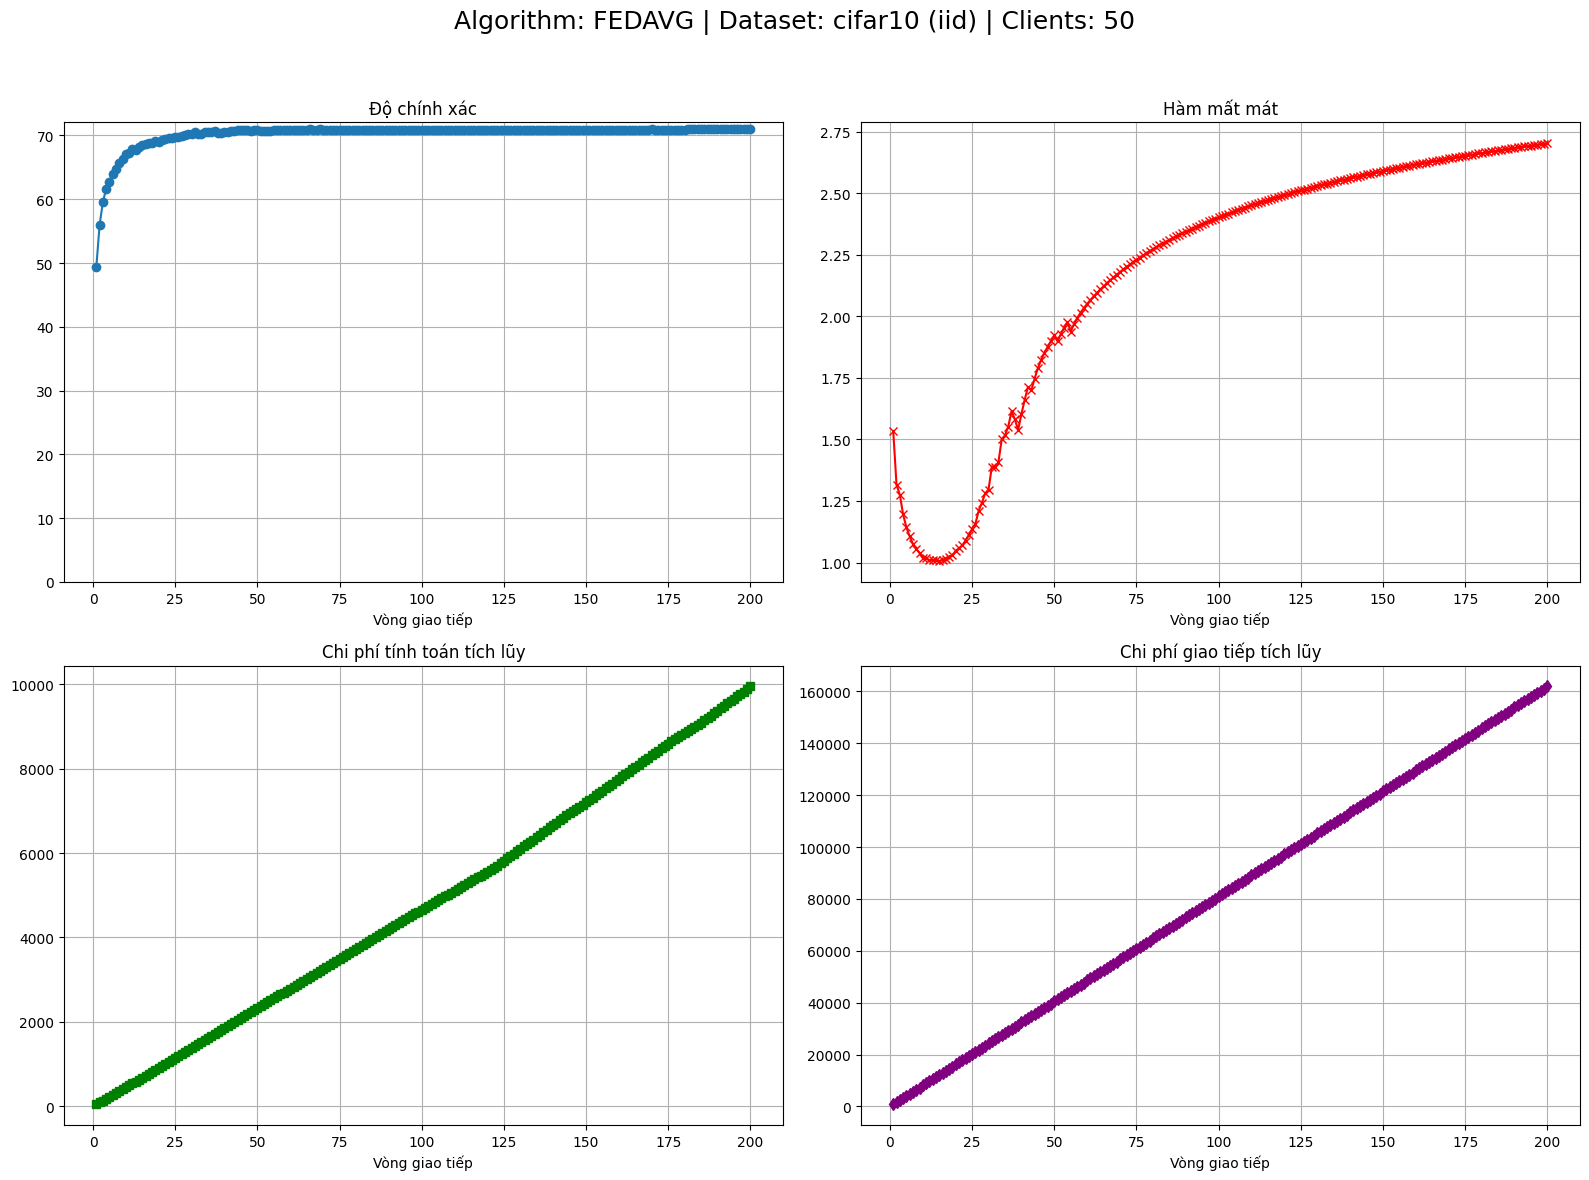

In [6]:
# Cell 6: Trực quan hóa kết quả 📊
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
title = (f"Algorithm: {config.ALGORITHM.upper()} | Dataset: {data_params['dataset_name']} "
         f"({data_params['distribution_mode']}) | Clients: {num_clients}")
fig.suptitle(title, fontsize=18)
rounds = history['rounds']
axes[0, 0].plot(rounds, history['accuracy'], marker='o'); axes[0, 0].set_title("Độ chính xác"); axes[0, 0].grid(True); axes[0, 0].set_ylim(bottom=0)
axes[0, 1].plot(rounds, history['loss'], marker='x', color='r'); axes[0, 1].set_title("Hàm mất mát"); axes[0, 1].grid(True)
axes[1, 0].plot(rounds, np.cumsum(history['comp_cost']), marker='s', color='g'); axes[1, 0].set_title("Chi phí tính toán tích lũy"); axes[1, 0].grid(True)
axes[1, 1].plot(rounds, np.cumsum(history['comm_cost']), marker='d', color='purple'); axes[1, 1].set_title("Chi phí giao tiếp tích lũy"); axes[1, 1].grid(True)
for ax in axes.flat: ax.set_xlabel("Vòng giao tiếp")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()